### This notebook compute "VCA4. Level of progress of the Climate Change Mitigation and Adaptation Plan " indicator for the 27 basins of IKI Project

Spanish: Nivel de avance del Plan de Mitigación y Adaptación al Cambio Climático

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:** 
**Status:** Complete and loaded in SQLite database. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad

 
**Inputs:**   Shapefile of COMIDs and districts, Excel of PMACC status for each EPS from Isabel Málaga del Ministerio de Vivienda, Construcción y Saneamiento 

**Outputs:** 
 
**Assumptions:** For now, given we don't have additional details, we are just giving a 0 or 1 depending on whether ot not they have an EPS at all. Any COMID that is touching the district with the EPS will get the PMACC association 

    1. I associated the attribute of if the EPS has PMACC or not (from AI2a_Metodologia\Indicadores\Vulnerabilidad\EPS_PMACC.xlsx) to the Demandas_EPS shapefile (Grupos_Modelacion\GIS_WaterALLOC_General\Demandas_EPS.shp)
    2. I assigned a 1 if the EPS has a PMACC, 0 if it does not. 
    3. I read in the district shapefile, and associated the district each EPS is located in.
    4. For each COMID, if it intersected with a district that has an EPS located within it, I assigned it the 'max' PMACC score (i.e. if one COMID intersected with 5 districts, and one of the districts had a PMACC, the COMID got a 1)
The guide says if a district (or in our case a COMID) does not have an EPS, assign NaN and do not include in the vulnerability equation.

**Future work:** 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 504 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [ ]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in PMACC Excel

PMACC = rf'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad\EPS_PMACC.xlsx'
pmacc_df = pd.read_excel(PMACC, sheet_name='Analisis')

#read in DEMANDAS_EPS shapefile
demandas_EPS = gpd.read_file(fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Demandas_EPS.shp")

#read in districts shapefile 
distritos = gpd.read_file(fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\BD_ANA.gdb", layer= 'Distrito')

In [ ]:
#FORMATTING THE DATAFRAMES

#make the second row the header 
pmacc_df.columns = pmacc_df.iloc[1]
pmacc_df = pmacc_df[2:]

#remove any columns that are completely NaN
pmacc_df = pmacc_df.dropna(axis=1, how='all')
#remove rows that have completely NaN values in the entire row 
pmacc_df = pmacc_df.dropna(how='all')

#rename column for easier access
pmacc_df = pmacc_df.rename(columns={'PMACC en formulación o finalizado, ha solicitado AT al MVCS': 'PMACC_Status'})

#trim down df to just EPS-Nombre, Cuenca (datos PACA), Localidades, PMACC_Status
pmacc_trimmed = pmacc_df[['EPS-Nombre', 'Cuenca (datos PACA)', 'Localidades', 'PMACC_Status']]
pmacc_trimmed


#ASSIGNING STATUS

#add PMACC status to demandas_EPS shapefile
demandas_EPS = demandas_EPS.merge(pmacc_trimmed, left_on='EPS-Nombre', right_on='EPS-Nombre', how='left')

In [ ]:
#ASSIGNING SCORES

#Add column of PMACC_score, based on PMACC_Status (SI= 1, NO=0, nan=NAN )
def pmacc_score(status):
    if status == 'SI':
        return 1
    elif status == 'NO':
        return 0
    else:
        return np.nan
demandas_EPS['PMACC_Score'] = demandas_EPS['PMACC_Status'].apply(pmacc_score)

#maintain only the columns EPS-Nombre, PMACC_Status, geometry
demandas_EPS_clean = demandas_EPS[['EPS-Nombre', 'PMACC_Score', 'geometry']]

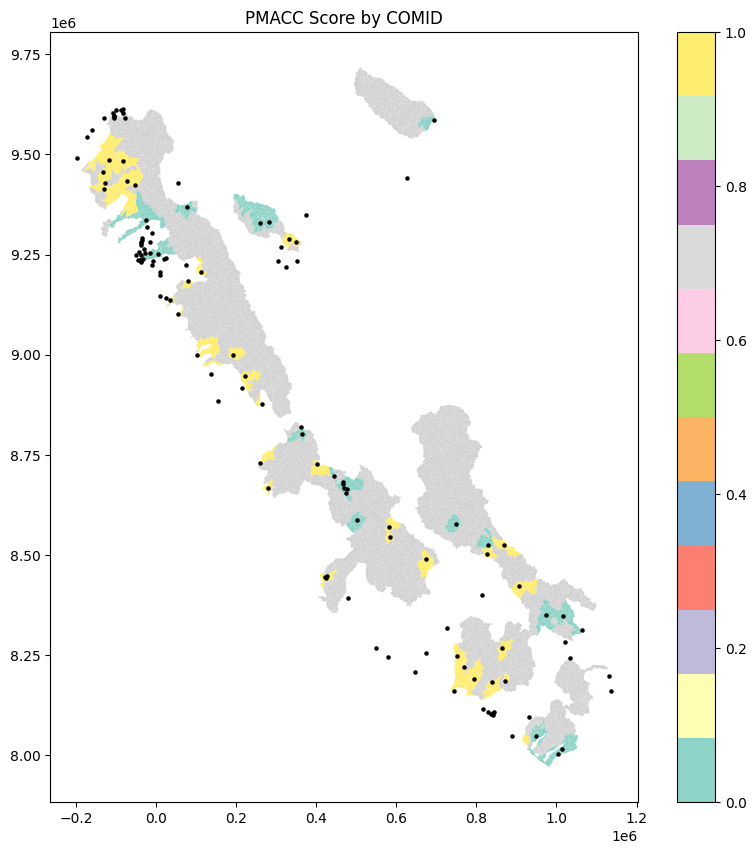

In [ ]:
#SPATIAL JOINS AND ASSIGNING PMACC SCORES TO SUBBASINS

#ensure both layers are in the same CRS as subbasins_gdf
distritos = distritos.to_crs(subbasins_gdf.crs)
demandas_EPS_clean = demandas_EPS_clean.to_crs(subbasins_gdf.crs)

#spatially join the EPS-Nombre, PMACC_Status to the district file
distritos_pmacc = gpd.sjoin(distritos, demandas_EPS_clean, how='left', predicate='intersects')

#if the COMID from subbasins_gdf intersects with the district, assign the PMACC status to the subbasin
subbasins_pmacc = gpd.sjoin(subbasins_gdf, distritos_pmacc[['ID_DIST', 'PMACC_Score', 'geometry']], how='left', predicate='intersects')
subbasins_pmacc = subbasins_pmacc[['COMID', 'ID_DIST', 'PMACC_Score', 'geometry']]

#clean up results so if a subbasin is associated with more than one district, it keeps the maximum PMACC_Score
subbasins_pmacc = subbasins_pmacc.sort_values(by='PMACC_Score', ascending=False).drop_duplicates(subset=['COMID'])

#PLOT RESULTS

#visually plot the results
fig, ax = plt.subplots(figsize=(10,10))
subbasins_pmacc.plot(column='PMACC_Score', ax=ax, legend=True, cmap='Set3', missing_kwds={'color': 'lightgrey', 'label': 'No data'})
#also plot EPS point locations from demandas_EPS_clean
demandas_EPS_clean.plot(ax=ax, color='black', markersize=5)
plt.title('PMACC Score by COMID')
plt.show()

PMACC Score for COMID 320254600: 1.0


C:\Users\sgilson\AppData\Local\Temp\ipykernel_33744\1342012139.py:44: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')


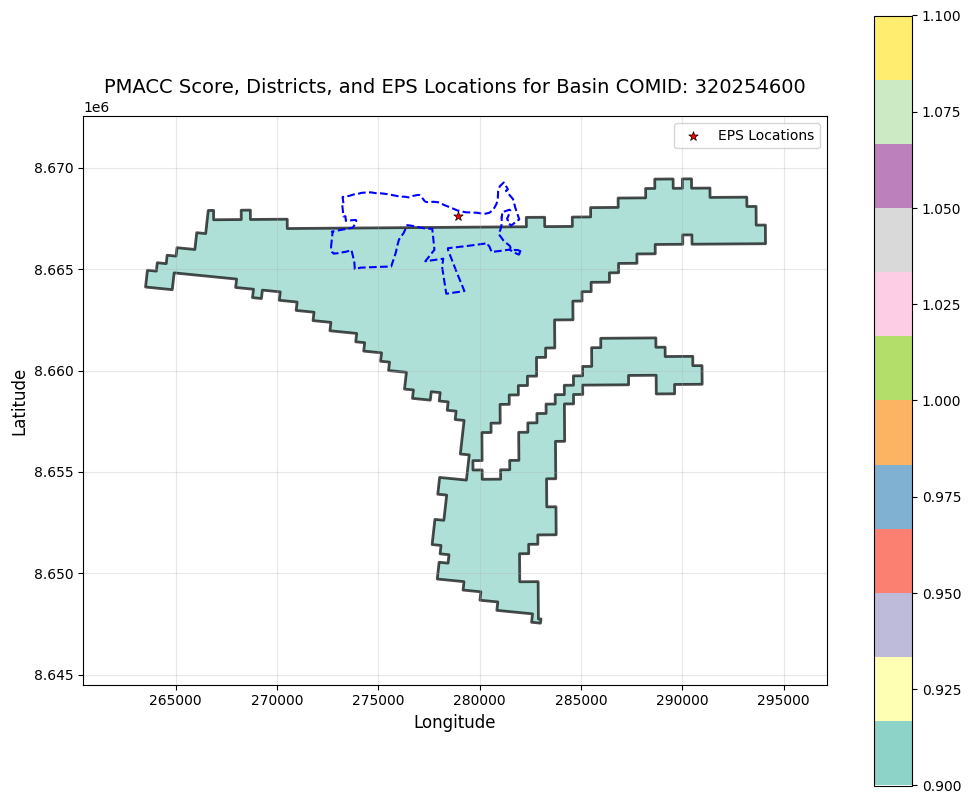

In [ ]:
#VISUAL QC OF A SPECIFIC BASIN

import matplotlib.pyplot as plt

# Specify the COMID to plot
target_comid = 320254600

# Filter the subbasin for the target COMID
target_basin = subbasins_pmacc[subbasins_pmacc['COMID'] == target_comid]

#print PMACC score for the target basin
print(f"PMACC Score for COMID {target_comid}: {target_basin['PMACC_Score'].values[0]}")

# Get the district ID(s) for this basin
target_districts = target_basin['ID_DIST'].unique()

# Filter districts that intersect with the target basin
districts_in_basin = distritos[distritos['ID_DIST'].isin(target_districts)]

# Initialize a plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the target subbasin with PMACC score
target_basin.plot(ax=ax, column='PMACC_Score', cmap='Set3', edgecolor='black', 
                  linewidth=2, alpha=0.7, legend=True,
                  missing_kwds={'color': 'lightgrey', 'label': 'No data'})

# Plot district boundaries
districts_in_basin.plot(ax=ax, facecolor='none', edgecolor='blue', 
                        linewidth=1.5, linestyle='--', label='District Boundary')

# Get the bounds of the target basin to set the extent
bounds = target_basin.total_bounds
buffer = 0.1 * max(bounds[2] - bounds[0], bounds[3] - bounds[1])  # 10% buffer
ax.set_xlim(bounds[0] - buffer, bounds[2] + buffer)
ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)

# Plot EPS points within or near the target basin
demandas_EPS_clean.plot(ax=ax, color='red', markersize=50, marker='*', 
                        edgecolor='black', linewidth=0.5, label='EPS Locations')

# Add title, legend, and labels
plt.title(f'PMACC Score, Districts, and EPS Locations for Basin COMID: {target_comid}', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='upper right')

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Show the plot
plt.show()

SQLITE INSERT 

In [13]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_pmacc #COMID and PMACC_Score
value_column= 'PMACC_Score' #Column with calculated indicator values

In [14]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [15]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [20]:
#summarize statistics for rows_to_insert
df_check.describe()

,ScnID,IndID,COMID,Value
count,3655.0,3655.0,3.655000e+03,662.000000
mean,1.0,504.0,3.085487e+08,0.554381
std,0.0,0.0,2.145454e+06,0.497410
min,1.0,504.0,3.042739e+08,0.000000
25%,1.0,504.0,3.066237e+08,0.000000
50%,1.0,504.0,3.091100e+08,1.000000
75%,1.0,504.0,3.102598e+08,1.000000
max,1.0,504.0,3.202546e+08,1.000000


In [22]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()

ProgrammingError: Cannot operate on a closed database.